Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

Load the Dataset

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Housing.csv to Housing.csv


In [3]:
df = pd.read_csv("Housing.csv")

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


Dataset Information

In [6]:
df.shape

(545, 13)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [8]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


Check Missing Values

In [9]:

df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


Check Duplicate Records

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [12]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


Separate Numerical & Categorical Columns

In [13]:
numerical_columns = df.select_dtypes(include=["int64","float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns

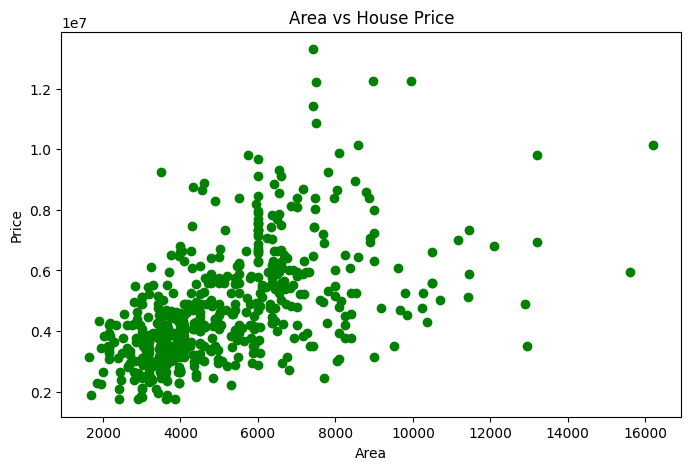

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(df["area"],df["price"],color="green")

plt.title("Area vs House Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.show()

Encode Categorical Columns

In [16]:
encoder = LabelEncoder()

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

Model Building

Separate Features and Target

In [17]:
X = df.drop("price", axis=1)
y = df["price"]

Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

Linear Regression Model

In [21]:
linear_model = LinearRegression()


In [22]:
linear_model.fit(X_train, y_train)

LinearRegression()

In [23]:
linear_prediction = linear_model.predict(X_test)

In [24]:
linear_train_score = linear_model.score(X_train, y_train)
linear_test_score = linear_model.score(X_test, y_test)

print("Training Score :", round(linear_train_score,3))
print("Testing Score  :", round(linear_test_score,3))

Training Score : 0.685
Testing Score  : 0.649


Decision Tree Regressor

In [25]:
decision_model = DecisionTreeRegressor(random_state=42)
decision_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [26]:
decision_prediction = decision_model.predict(X_test)

In [27]:
decision_train_score = decision_model.score(X_train, y_train)

decision_test_score = decision_model.score(X_test, y_test)

print("Training Score :", round(decision_train_score,3))
print("Testing Score  :", round(decision_test_score,3))

Training Score : 0.999
Testing Score  : 0.468


Random Forest Regressor

In [32]:
random_model = RandomForestRegressor(n_estimators=100,random_state=42)


In [33]:
random_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [34]:
random_prediction = random_model.predict(X_test)

In [35]:
random_train_score = random_model.score(X_train, y_train)

random_test_score = random_model.score(X_test, y_test)

print("Training Score :", round(random_train_score,3))
print("Testing Score  :", round(random_test_score,3))

Training Score : 0.949
Testing Score  : 0.612


KNN

Feature Scaling for KNN

In [36]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [37]:
knn_model = KNeighborsRegressor(n_neighbors=5)

In [38]:
knn_model.fit(X_train_scaled, y_train)

KNeighborsRegressor()

In [39]:
knn_prediction = knn_model.predict(X_test_scaled)


In [40]:
knn_train_score = knn_model.score(X_train_scaled, y_train)

knn_test_score = knn_model.score(X_test_scaled, y_test)

print("Training Score :", round(knn_train_score,3))
print("Testing Score  :", round(knn_test_score,3))

Training Score : 0.747
Testing Score  : 0.583


In [42]:
print("Model Performance")
print(f"Linear Regression Train Score : {linear_train_score:.3f}")
print(f"Linear Regression Test Score  : {linear_test_score:.3f}")

print()

print(f"Decision Tree Train Score : {decision_train_score:.3f}")
print(f"Decision Tree Test Score  : {decision_test_score:.3f}")

print()

print(f"Random Forest Train Score : {random_train_score:.3f}")
print(f"Random Forest Test Score  : {random_test_score:.3f}")

print()

print(f"KNN Train Score : {knn_train_score:.3f}")
print(f"KNN Test Score  : {knn_test_score:.3f}")


Model Performance
Linear Regression Train Score : 0.685
Linear Regression Test Score  : 0.649

Decision Tree Train Score : 0.999
Decision Tree Test Score  : 0.468

Random Forest Train Score : 0.949
Random Forest Test Score  : 0.612

KNN Train Score : 0.747
KNN Test Score  : 0.583


Model Evaluation & Prediction

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [44]:
def evaluate_model(y_test, prediction):

    mae = mean_absolute_error(y_test, prediction)
    mse = mean_squared_error(y_test, prediction)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, prediction)

    return [mae, mse, rmse, r2]

In [45]:
linear_metrics = evaluate_model(y_test, linear_prediction)
decision_metrics = evaluate_model(y_test, decision_prediction)
random_metrics = evaluate_model(y_test, random_prediction)
knn_metrics = evaluate_model(y_test, knn_prediction)

Compare Models

In [46]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],

    "R² Score":[
        linear_metrics[3],
        decision_metrics[3],
        random_metrics[3],
        knn_metrics[3]
    ],

    "RMSE":[
        linear_metrics[2],
        decision_metrics[2],
        random_metrics[2],
        knn_metrics[2]
    ]

})

comparison

,Model,R² Score,RMSE
0,Linear Regression,0.649475,1.331071e+06
1,Decision Tree,0.468169,1.639566e+06
2,Random Forest,0.611532,1.401263e+06
3,KNN,0.583257,1.451364e+06


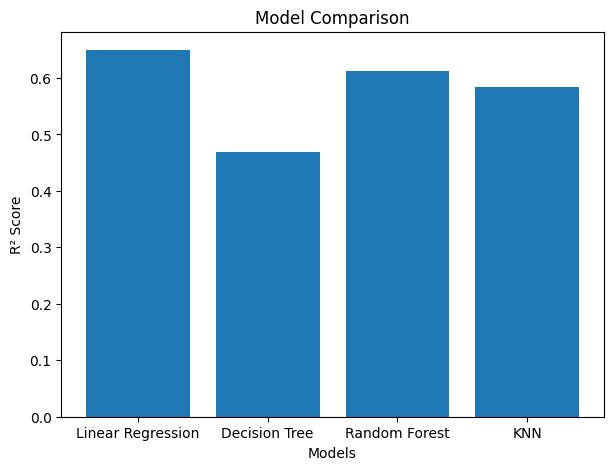

In [47]:
plt.figure(figsize=(7,5))

plt.bar(comparison["Model"], comparison["R² Score"])

plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("R² Score")

plt.show()

Predict House Price

In [48]:
sample_house = [[
    7420,
    4,
    2,
    3,
    1,
    0,
    1,
    0,
    1,
    2,
    1,
    2
]]

predicted_price = random_model.predict(sample_house)

print("Predicted House Price : ₹{:,.2f}".format(predicted_price[0]))

Predicted House Price : ₹8,706,448.80


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
